<a href="https://colab.research.google.com/github/riddo999/Sentiment/blob/main/sentiment-analysis-IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install transformers datasets scikit-learn matplotlib seaborn -q

In [3]:
#Import libraries
from transformers import pipeline
from datasets import load_dataset
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Load the model
print("Loading model...")
classifier = pipeline("sentiment-analysis",
                     model="distilbert-base-uncased-finetuned-sst-2-english")
print("✅ Model loaded successfully!")

# Load IMDB dataset (we'll use a small subset for speed)
print("Loading dataset...")
dataset = load_dataset("imdb", split="test")  # First 1000 test examples
dataset  = dataset.shuffle (seed=42).select(range(1000))
print(f"✅ Dataset loaded {len(dataset)} reviews ready for evaluation!")

# Verify balance
label_counts = Counter(dataset['label'])
print(f"...Negative reviews: {label_counts[0]}")
print(f"...Positive reviews: {label_counts[1]}")

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

...

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Dataset loaded 1000 reviews ready for evaluation!
...Negative reviews: 512
...Positive reviews: 488


In [5]:
# Function to predict on batch
def predict_sentiment(texts, batch_size=32):
    """
    Predict sentiment for a list of texts in batches.
    """

    predictions = []
    totalbatches = (len(texts) + batch_size - 1) // batch_size

    print(f"Processing {len(texts)} reviews in {totalbatches}) batches...")

    for batch_num, i in enumerate(range(0, len(texts), batch_size), 1):
        batch = texts[i:i+batch_size]
        results = classifier(batch, truncation=True, max_length=512)
        predictions.extend(results)

        #Progress indicator
        if batch_num % 10 == 0 or batch_num == totalbatches:
            print(f"Processed batch {batch_num}/{totalbatches} ")

    return predictions

# Get predictions
print("Making predictions on 1000 reviews...   ")
texts = dataset['text']
predictions = predict_sentiment(texts)

#Convert predictions to binary lables
pred_labels = [1 if p['label'] == 'POSITIVE' else 0 for p in predictions]
true_labels = list(dataset['label'])

print(f"\n✅ Converted {len(pred_labels)} predictions to binary labels.")

Making predictions on 1000 reviews...   
Processing 1000 reviews in 32) batches...
Processed batch 10/32 
Processed batch 20/32 
Processed batch 30/32 
Processed batch 32/32 

✅ Converted 1000 predictions to binary labels.


In [6]:
# Determine accuracy and evaluation results
accuracy = accuracy_score(true_labels, pred_labels)

print("="*70)
print("EVALUATION RESULTS")
print("="*70)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Correct Predictions: {sum(np.array(true_labels) == np.array(pred_labels))} / {len(true_labels)}")

print("\nDetailed Classification Report:")
print(classification_report(true_labels, pred_labels,
                            target_names=['Negative', 'Positive']))

EVALUATION RESULTS

Accuracy: 0.8810 (88.10%)
Correct Predictions: 881 / 1000

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.90      0.89       512
    Positive       0.89      0.86      0.88       488

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



In [7]:
# Calculate confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

In [8]:
# Create visualisation
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

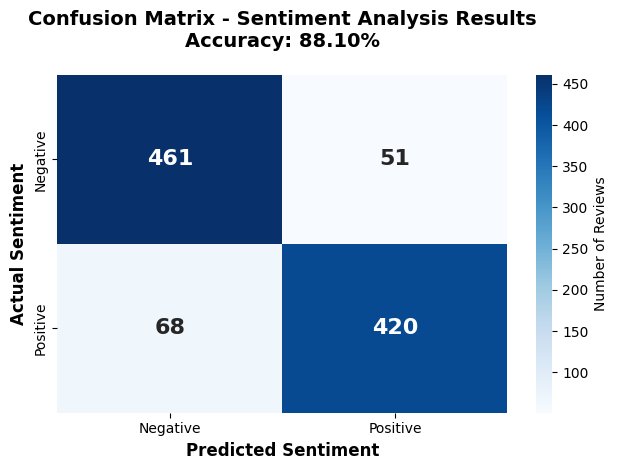

✅ Confusion matrix saved as 'confusion_matrix.png'!


In [9]:
sns.heatmap(cm,
           annot=True,
           fmt='d',
           cmap='Blues',
           xticklabels=['Negative', 'Positive'],
           yticklabels=['Negative', 'Positive'],
           cbar_kws={'label': 'Number of Reviews'},
           annot_kws={'size': 16,'weight': 'bold'})

plt.xlabel('Predicted Sentiment', fontsize=12, weight='bold')
plt.ylabel('Actual Sentiment', fontsize=12, weight='bold')
plt.title('Confusion Matrix - Sentiment Analysis Results\n' +
          f'Accuracy: {accuracy:.2%}',
          fontsize=14, weight='bold',pad=20)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300,bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved as 'confusion_matrix.png'!")

In [10]:
# Extract values from confusion matrix
tn, fp, fn, tp = cm.ravel()

print("="*70)
print("CONFUSION MATRIX BREAKDOWN")
print("="*70)
print(f"\nTrue Negatives (TN): {tn}")
print(f" ✅ Correctly identified as NEGATIVE: {tn} reviews")

print(f"\nFalse Positives (FP): {fp}")
print(f" ❌ Incorrectly identified as POSITIVE: {fp} reviews")

print(f"\nFalse Negatives (FN): {fn}")
print(f" ❌ Incorrectly identified as NEGATIVE: {fn} reviews")

print(f"\nTrue Positives (TP): {tp}")
print(f" ✅ Correctly identified as POSITIVE: {tp} reviews")

print("\n")
print("KEY INSIGHTS:")
print("=" * 70)

# Calculate error rates
false_positive_rate = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0

print(f"\n False Positive Rate: {false_positive_rate:.2f}%")
print(f"  (Model incorreclty calls negative reviews positive)")

print(f"\n False Negative Rate: {false_negative_rate:.2f}%")
print(f"  (Model incorrectly calls positive reviews negative)")

if false_positive_rate > false_negative_rate:
    print("\n⚠️ The model tends to be OPTIMISTIC (over predicted postive).")
elif false_negative_rate > false_positive_rate:
    print("\n⚠️ The model tends to be PESSIMISTIC (over predicted negative).")
else:
    print("\n✅ The model has a BALANCED in its errors.")

CONFUSION MATRIX BREAKDOWN

True Negatives (TN): 461
 ✅ Correctly identified as NEGATIVE: 461 reviews

False Positives (FP): 51
 ❌ Incorrectly identified as POSITIVE: 51 reviews

False Negatives (FN): 68
 ❌ Incorrectly identified as NEGATIVE: 68 reviews

True Positives (TP): 420
 ✅ Correctly identified as POSITIVE: 420 reviews


KEY INSIGHTS:

 False Positive Rate: 9.96%
  (Model incorreclty calls negative reviews positive)

 False Negative Rate: 13.93%
  (Model incorrectly calls positive reviews negative)

⚠️ The model tends to be PESSIMISTIC (over predicted negative).


In [11]:
print("="*70)
print("EXAMPLE MISCLASSIFICATIONS")
print("="*70)

#Find misclassified examples
errors = []
for i, (true, pred) in enumerate(zip(true_labels, pred_labels)):
    if true != pred:
        errors.append({
            'index': i,
            'text':texts[i],
            'true':'Positive' if true == 1 else 'Negative',
            'predicted':'Positive' if pred == 1 else 'Negative',
            'confidence': predictions[i]['score']
        })

print(f"\nFound {len(errors)} misclassified reviews out of {len(true_labels)}")
print(f"Error rate: {len(errors)/len(true_labels)*100:.2f}%")

#Show high-confidence errors (most interesting)
high_conf_errors = [e for e in errors if e['confidence'] > 0.9]
print(f"\nHigh-confidence errors (>90% confidence): {len(high_conf_errors)}")

print("\n" + "-"*70)
print("TOP 5 MISCLASSIFIED (Most confidence mistakes)")
print("-"*70)

for i,error in enumerate(sorted(high_conf_errors,
                              key=lambda x: x['confidence'],
                              reverse=True)[:5],1):
    print(f"\n[i]. Review (first 200 chars):")
    print(f"    {error['text'][:200]}...")
    print(f"    ✓ Actual: {error['true']}")
    print(f"    ✘ Predicted: {error['predicted']} (confidence: {error['confidence']:.2%})")

EXAMPLE MISCLASSIFICATIONS

Found 119 misclassified reviews out of 1000
Error rate: 11.90%

High-confidence errors (>90% confidence): 92

----------------------------------------------------------------------
TOP 5 MISCLASSIFIED (Most confidence mistakes)
----------------------------------------------------------------------

[i]. Review (first 200 chars):
    Going into the movie with the right expectations, I somewhat liked this movie. Like most reviewers who have seen this movie, I fully agree that the plot was razor thin, clichéd, and I could predict ev...
    ✓ Actual: Negative
    ✘ Predicted: Positive (confidence: 99.97%)

[i]. Review (first 200 chars):
    Sex, drugs, racism and of course you ABC's. What more could you want in a kid's show!<br /><br />------------------------------------------- -------------------------------------------<br /><br />"Use...
    ✓ Actual: Positive
    ✘ Predicted: Negative (confidence: 99.95%)

[i]. Review (first 200 chars):
    Early 1950s Sci-F